### Evasion dataset 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from scipy import *
from sklearn.feature_selection import SelectKBest, f_regression
import joblib
import os
import logging
import yaml
from pathlib import Path


In [3]:
# configs 
my_font = dict(
            family="Courier New, monospace",
            size=18,
            color="Black",
            variant="small-caps",
) 

## Loading datasets

In [4]:
"""
Loading the datasets

"""
def get_config_file(): 
    try:
        base_dir = Path(__file__).resolve().parent.parent
        path = base_dir / "configs" / "training.yaml"
        return path
    except NameError: # if it is a jupyter file 
        return Path("/training-app/configs/training.yaml")


def load_config(CONFIG_PATH) :
  """
  Selects the current dataset's config file we are interest in.
  """
  try:
      with open(CONFIG_PATH, "r") as f:
        full_config = yaml.safe_load(f)
  except Exception as e:
    print(f"Config file not found {e}")
    raise


  try:
    current_dataset = full_config["CURRENT_DATASET"]
    print(f"\nloading current dataset: {current_dataset}")
    if current_dataset not in full_config['DATASETS']:
      raise ValueError(f"\nDataset {current_dataset} not found!")

    return full_config["DATASETS"][current_dataset]

  except Exception as e:
    print(f"There was an error handling the config cleaning.yaml file {e}")
    raise


CONFIG_PATH = get_config_file()
dfs = load_config(CONFIG_PATH)


loading current dataset: CIENCIA_DA_COMPUTACAO


### Selecting desired dataset -> df_train


In [5]:
"""
Selecting desired dataset -> df_train
"""
df_train = pd.read_csv(dfs['TRAINING_DATASET'])
df_active = pd.read_csv(dfs['ACTIVE_DATASET'])
df_deactive = pd.read_csv(dfs['EVADED_DATASET'])
df_history = pd.read_csv(dfs['HISTORY_DATASET'])

## Checking the general info of the dataset

We need to extract the following features:
    - For each semester, we need to calculate the CR - Coeficiente de Rendimento
    - The total Amount of failings per semester 
    - The total Diciplines made per semester (Credits)
    - CR_Trend - Change in CR from last semester (Coeficiente)
    - Failure_rate - % of subjects failed so far
    - % of subjects failed so far
    - Delayed_Progress	Are they behind schedule?


- We must create the Lag_Academico
  - Tempo_de_Permanenca - Idade_Academica 
    - Lag 0   -> The student is on track
    - Lag > 2 -> The student is behind
    - Lag < 0 -> The student is an overachiever 

- We can also create the Velocidade_Progresso
  - ( Idade_Academica / Tempo_de_Permanencia )  
  - 1.0 -> velocidade ok
  - 0.5 -> Student taking 2x to finish the classes

## Handling History dataset - this later on will be a dag in airflow

In [164]:
df_history_v0 = df_history.copy()
df_history_v0 = df_history_v0.sort_values(by='RGA_Anon')
df_history_v0.drop(columns={"Faltas", "Codigo_Turma", "Equivalencia", "Codigo_Disciplina", "Curso_Ofertante", "Observacao", "Ano"}, inplace=True)

In [165]:
"""
Here, we'll consider failure to a subject as 1 and non-failure as 0
    - MA will be disconsidered

"""
df_history_v0 = df_history_v0[df_history_v0['Situação'] != "MA"]
failures = ['RMF', 'RM', 'RP', 'RF']

df_history_v0['Situação']  = np.where(
    df_history_v0['Situação'].isin(failures),
    1,
    0
)

In [182]:
"""
Here we calculate the weighted faiulure - Reprovacao_Ponderada_Semestral - How many credits did the student fail
"""
def calculate_weighted_failured( df: pd.DataFrame) -> pd.DataFrame:
    
    df['Reprovacao_Ponderada_Semestral'] = df["Crédito"].to_numpy() * df["Situação"].to_numpy()

    df['Reprovacao_Ponderada_Semestral'] = (
        df.groupby(["AnoSem",  "RGA_Anon"])["Reprovacao_Ponderada_Semestral"]
        .transform("sum")
    )

    return df
df_history_v2 = calculate_weighted_failured(df_history_v0)

In [183]:
"""
Here we calculate - [Reprovação_Media_Semestral] - how much percent of the total credits taken does the student fail

    - 0.0 -> student did not fail a single one subject
    - 1.0 -> student failed all subjects
"""
def calculate_failure_ratio (df: pd.DataFrame) -> pd.DataFrame:
    total_credit = df.groupby(["AnoSem",  "RGA_Anon"])['Crédito'].transform("sum").to_numpy() 
    total_credit = total_credit.astype("float")

    df['Reprovacao_Ponderada_Semestral'] = df['Reprovacao_Ponderada_Semestral'].astype("float")
    
    df['Reprovação_Media_Semestral']  = (df['Reprovacao_Ponderada_Semestral'].to_numpy()  / total_credit)

    return df
df_history_v3 = calculate_failure_ratio(df_history_v2)

/tmp/ipykernel_9/1197268355.py:13: RuntimeWarning: invalid value encountered in divide
  df['Reprovação_Media_Semestral']  = (df['Reprovacao_Ponderada_Semestral'].to_numpy()  / total_credit)


In [168]:
df_history_v3['AnoSem'] = ( 
    np.where(df_history_v3['AnoSem'] % 1 == .5,
    df_history_v3['AnoSem'] -.3,
    df_history_v3['AnoSem'] +.1
    ) 
    )

In [169]:
"""
Here, we will need the - Período ingresso - feature to calculate the permanence time
"""

all_students = pd.concat([df_active, df_deactive], axis=0)
df_history_v4 = df_history_v3.merge(all_students[['RGA_Anon', 'Período ingresso']], on='RGA_Anon', how='left')

In [170]:
periodo_ingresso = sorted(df_history_v4['Período ingresso'].unique())

print("As noted, we have an entrance date starting in 2009. But, at the same time, we got disciplines happening already in 2006")
display(periodo_ingresso)

all_ano = sorted(df_history_v4['AnoSem'].unique())
display(all_ano)

print("We must therefore drop all the history that happened before 2009")


As noted, we have an entrance date starting in 2009. But, at the same time, we got disciplines happening already in 2006


[np.int64(20091),
 np.int64(20101),
 np.int64(20111),
 np.int64(20121),
 np.int64(20131),
 np.int64(20141),
 np.int64(20151),
 np.int64(20161),
 np.int64(20162),
 np.int64(20171),
 np.int64(20172),
 np.int64(20181),
 np.int64(20191),
 np.int64(20201),
 np.int64(20211),
 np.int64(20221),
 np.int64(20222),
 np.int64(20231),
 np.int64(20232),
 np.int64(20241),
 np.int64(20242),
 np.int64(20251)]

[np.float64(2006.2),
 np.float64(2007.1),
 np.float64(2008.1),
 np.float64(2009.1),
 np.float64(2009.2),
 np.float64(2010.1),
 np.float64(2010.2),
 np.float64(2011.1),
 np.float64(2011.2),
 np.float64(2012.1),
 np.float64(2012.2),
 np.float64(2013.1),
 np.float64(2013.2),
 np.float64(2014.1),
 np.float64(2014.2),
 np.float64(2015.1),
 np.float64(2015.2),
 np.float64(2016.1),
 np.float64(2016.2),
 np.float64(2017.1),
 np.float64(2017.2),
 np.float64(2018.1),
 np.float64(2018.2),
 np.float64(2019.1),
 np.float64(2019.2),
 np.float64(2020.1),
 np.float64(2020.2),
 np.float64(2021.1),
 np.float64(2021.2),
 np.float64(2022.1),
 np.float64(2022.2),
 np.float64(2023.1),
 np.float64(2023.2),
 np.float64(2024.1),
 np.float64(2024.2),
 np.float64(2025.1),
 np.float64(2025.2),
 np.float64(2026.1)]

We must therefore drop all the history that happened before 2009


In [181]:
"""
Here, we will get only the semesters starting from 2009.1
"""
df_history_v5 = df_history_v4.copy()
df_history_v5 = df_history_v5[df_history_v5['AnoSem'] >= 2009.1]
# display(sorted(df_history_v5['AnoSem'].unique()))


In [177]:
""""
Now we enumerate these semesters inorder to calculate the total_num_semesters the students has been since enrollement
"""

def calculate_permanence_period_in_semesters(df: pd.DataFrame) -> pd.DataFrame:

    df['Período ingresso'] = df['Período ingresso'].astype('float')

    df['Período ingresso']  = df['Período ingresso'] / 10

    all_values_unique = pd.concat([
    df['AnoSem'],
    df['Período ingresso']
    ]).dropna().unique()

    all_values_sorted = sorted(all_values_unique)
    mapping = {val: i+1 for i, val in enumerate(all_values_sorted)}

    df['AnoSemIdOrdered'] = df['AnoSem'].map(mapping)
    df['PeriodoIngressoIdOrdered'] = df['Período ingresso'].map(mapping)

    df['Tempo_Permanencia_Em_Semestres']  = abs(df['PeriodoIngressoIdOrdered'] - df['AnoSemIdOrdered']) + 1

    df.drop(columns={'AnoSemIdOrdered', 'PeriodoIngressoIdOrdered'}, inplace=True)
    return df


df_history_v6 = df_history_v5.copy()
df_history_v6 = calculate_permanence_period_in_semesters(df_history_v6)

In [178]:
""" Now we will calculate the academic lag """

def calculate_academic_lag_in_semesters(df: pd.DataFrame, Tempo_Permanencia_Em_Semestres: str , Idade_Academica: str, Lag_Academico_Em_Semestres: str ) -> pd.DataFrame:
    df[Lag_Academico_Em_Semestres] = abs(df[Tempo_Permanencia_Em_Semestres] - df[Idade_Academica])
    return df

df_history_v7 = df_history_v6.copy()
df_history_v7 = calculate_academic_lag_in_semesters(df_history_v7, "Tempo_Permanencia_Em_Semestres", "Idade_Academica", "Lag_Academico_Em_Semestres")

In [202]:
"""  We will now calculate some important deltas 
        - Lag_Delta-> the lag is increasing or decreasing 
        - MG_Delta -> the MG is increasing or decreasing 
"""
def calculate_lag_delta(df: pd.DataFrame, lag_column: str) -> pd.DataFrame: 
    df = df.sort_values(by=['RGA_Anon', "Tempo_Permanencia_Em_Semestres"])
    df['Lag_Delta'] = df.groupby('RGA_Anon')[lag_column].diff().fillna(0)
    return df 

def calculate_mg_delta (df: pd.DataFrame, mg_column: str) -> pd.DataFrame: 
    df = df.sort_values(by=['RGA_Anon', "Tempo_Permanencia_Em_Semestres"])
    df['MG_Delta'] = df.groupby('RGA_Anon')[mg_column].diff().fillna(0)
    return df 


df_history_v8 = df_history_v7.copy()
df_history_v8 = calculate_lag_delta(df_history_v8, "Lag_Academico_Em_Semestres")
df_history_v8 = calculate_mg_delta(df_history_v8, "MG_Semestre")

In [211]:
def calculate_deltas_fixed(df: pd.DataFrame) -> pd.DataFrame:
    # 1. Ensure chronological order
    df = df.sort_values(by=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])


    sem_snapshot = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres']).agg({
        'Lag_Academico_Em_Semestres': 'first',
        'MG_Semestre': 'first'
    }).reset_index()

    sem_snapshot['Lag_Delta'] = sem_snapshot.groupby('RGA_Anon')['Lag_Academico_Em_Semestres'].diff().fillna(0)
    sem_snapshot['MG_Delta'] = sem_snapshot.groupby('RGA_Anon')['MG_Semestre'].diff().fillna(0)

    df = df.drop(columns=['Lag_Delta', 'MG_Delta'], errors='ignore') # Clean up if they exist
    df = df.merge(
        sem_snapshot[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Lag_Delta', 'MG_Delta']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    
    return df

df_history_v8 = calculate_deltas_fixed(df_history_v7.copy())

In [210]:
df_history_v8.head(15)

,CH,Crédito,Nota,Situação,Nome_Disciplina,Semestre,Frequencia,Falta_Excessiva,Percentual_Faltas,AnoSem,...,Total_CH_Semestre,MG_Semestre,RGA_Anon,Reprovacao_Ponderada_Semestral,Reprovação_Media_Semestral,Período ingresso,Tempo_Permanencia_Em_Semestres,Lag_Academico_Em_Semestres,Lag_Delta,MG_Delta
0,96,6,0.00,1,GEOMETRIA ANALÍTICA E VETORIAL,1,0.000000,1,1.000000,2015.1,...,448,2.500,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.785714,2015.1,1,1.0,0.0,0.000
1,64,4,1.50,1,FUNDAMENTOS DE MATEMÁTICA,1,62.500000,1,0.375000,2015.1,...,448,2.500,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.785714,2015.1,1,1.0,0.0,0.000
2,96,6,2.30,1,Lógica Matemática e Elementos de Lógica Digital,1,83.333333,0,0.166667,2015.1,...,448,2.500,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.785714,2015.1,1,1.0,0.0,0.000
3,96,6,6.00,0,Práticas de Leitura e Produção de Textos,1,77.083333,0,0.229167,2015.1,...,448,2.500,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.785714,2015.1,1,1.0,0.0,0.000
4,96,6,2.70,1,Programação I,1,58.333333,1,0.416667,2015.1,...,448,2.500,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.785714,2015.1,1,1.0,0.0,0.000
5,96,6,0.41,1,Programação I,2,85.416667,0,0.145833,2015.2,...,416,1.962,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.846154,2015.1,2,1.5,0.5,-0.538
6,96,6,2.20,1,MECÂNICA,2,91.666667,0,0.083333,2015.2,...,416,1.962,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.846154,2015.1,2,1.5,0.5,-0.538
7,96,6,0.00,1,GEOMETRIA ANALÍTICA E VETORIAL,2,89.583333,0,0.104167,2015.2,...,416,1.962,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.846154,2015.1,2,1.5,0.5,-0.538
8,64,4,2.20,1,FUNDAMENTOS DE MATEMÁTICA,2,93.750000,0,0.062500,2015.2,...,416,1.962,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.846154,2015.1,2,1.5,0.5,-0.538
9,64,4,5.00,0,ESTATISTICA GERAL,2,100.000000,0,0.000000,2015.2,...,416,1.962,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.846154,2015.1,2,1.5,0.5,-0.538


In [61]:
datasets = [deactive, active]

for i in datasets:
    df_test = i.copy()
    df_test['Data ocorrência'] = pd.to_datetime(df_test['Data ocorrência'])
    df_test['Data Nascimento']= pd.to_datetime(df_test['Data Nascimento'])

    filtered = (df_test['Período'] / 10).astype(int)
    filtered = pd.to_datetime(filtered, format='%Y', errors='coerce')
    
    i['Data ocorrência'] = np.where(
        df_test['Data ocorrência'].isna(),
        filtered,
        df_test['Data ocorrência']
    )
        
    df_test['Difference'] = ((i['Data ocorrência'] - df_test['Data Nascimento']).dt.days / 365.0)
    i.loc[:,'Idade'] = df_test['Difference']

    
finished = deactive[deactive['Situação atual'] == 'EXCLUSAO POR CONCLUSAO (FORMADO)']
dropout = deactive[deactive['Situação atual'] != 'EXCLUSAO POR CONCLUSAO (FORMADO)']


In [62]:
# Normalizing names from Naturalidade column

def normalize_names(text):
    if pd.isnull(text):
        return text
    text = str(text)
    text = unidecode.unidecode(text)
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = text.title()
    return text


## Correcting mispelled cities

In [63]:
def match_cities_name(df: pd.DataFrame, column: str) -> pd.DataFrame:
    regex_mapping = {
        r".*cuiaba.*|.*CUIABA.*|.*Cuiabamt.*": "Cuiabá",
        r".*aragarcas.*|.*Aragarcasgo.*|.*ARAGARÇAS.*": "Aragarças",
        r".*barra do garcas.*|.*Barra Do Garcas.*|.*BARRA DO GARÇAS.*": "Barra Do Garças",
        r".*alta floresta.*|.*Alta Floresta.*|.*ALTA FLORESTA.*": "Alta Floresta",
        r".*nova xavantina.*|.*Nova Xavantina.*": "Nova Xavantina",
        r".*baliza.*|.*Baliza Go.*": "Baliza",
        r".*rondonopolis.*|.*Rondonopolitano.*": "Rondonópolis",
        r".*braganca.*|.*Braganca Pa.*": "Bragança",
        r".*palmitos.*|.*Palmitossc.*": "Palmitos",
        r".*vazante.*|.*Vazante Mg.*": "Vazante",
        r".*jussara.*|.*Jussarago.*": "Jussara",
        r".*rio branco.*|.*Rio Branco  Mt.*": "Rio Branco",
        r".*mato grosso.*|.*Mato Grossointerior.*": "Mato Grosso",
        r".*chapeco.*|.*Chapecosc.*": "Chapecó",
        r".*agua boa.*|.*Agua Boamt.*": "Água Boa",
        r".*sao joaquim.*|.*Sao Joaquim Sc.*": "São Joaquim",
        r".*Brasilia.*|.*df.*|.*brasilia.*": "Brasília",
        r".*Goiania.*|.*goianiago.*|.*Goiânia.*": "Goiânia",
        r".*São Paulo.*|.*Sao Paulo.*|.*sao paulo.*": "São Paulo"


    }
    try:

      df.loc[:, column] = df[column].apply(normalize_names)

      def apply_regex(name):
        if not isinstance(name, str):
            return name
        for pattern, correct_name in regex_mapping.items():
            if re.search(pattern, name, re.IGNORECASE):
                return correct_name
        return name
        
      if column in df.columns:  
        df.loc[:, column] = df[column].apply(apply_regex)
        return df
      raise KeyError(f"Column {column} does not exist")
      
    except KeyError as e:
      print(f"Column {e} does not exist in dataset.")
    except RuntimeError as e:
      print(f"Can't fill data{e}")

datasets = [deactive, dropout, active, finished]
for df in datasets:
    df = match_cities_name(df, "Naturalidade")



In [64]:
print(df['Naturalidade'].unique())

['Paragominas' 'Barra Do Garças' 'Umuarama' 'Guirantiga' 'Campo Grande'
 'Goiânia' 'Sorriso' 'Peixoto De Azevedo' 'Ariquemes' 'Crateus'
 'Querencia' 'Sao Felix Do Araguaia' 'Aragarças' 'Sao Miguel Do Araguaia'
 'Guarulhos' 'Imperatriz' 'Canarana' 'Uruacu' 'Anapolis'
 'Lauro De Freitas' 'Trindade' 'Bela Vista De Goias' 'Vatuporanga'
 'Matrincha' 'Ibotirama' 'Jussara' 'Cuiabá' 'Água Boa' 'Iturama'
 'Varzea Grande' 'Primavera Do Leste' 'Rondonópolis' 'General Carneiro'
 'São Paulo' 'Barreiras' 'Conceicao Do Castelo' 'Piracanjuba' 'Catanduva'
 'Aldeias Altas' 'Santa Fe Do Sul' 'Vitoria' 'Quirinopolis'
 'Nova Xavantina' 'Resende' 'Londrina' 'Ipora' 'Ouro Preto Do Oeste'
 'Bragança' 'Jatai' 'Brasília' 'Piranhas' 'Formosa' 'Bom Jardim De Goias'
 'Juina' 'Pitangui' nan 'Apiacas' 'Belo Horizonte' 'Guiratinga' 'Jiparana'
 'Uruana']


## Group comparasion Finished vs Dropout


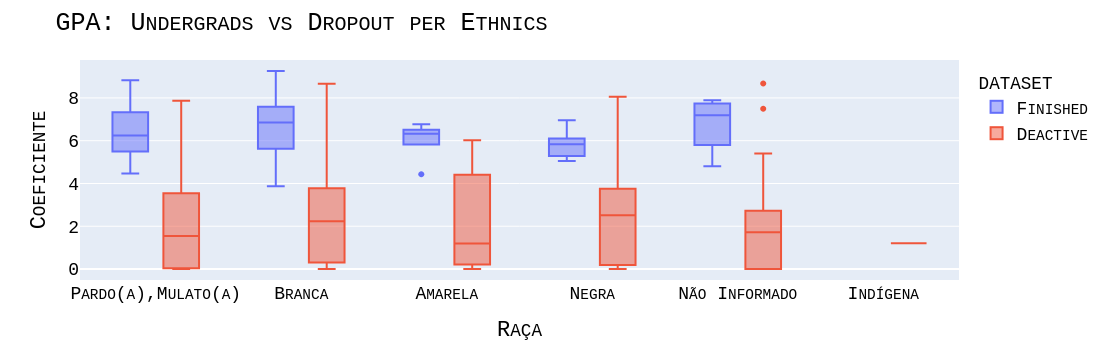

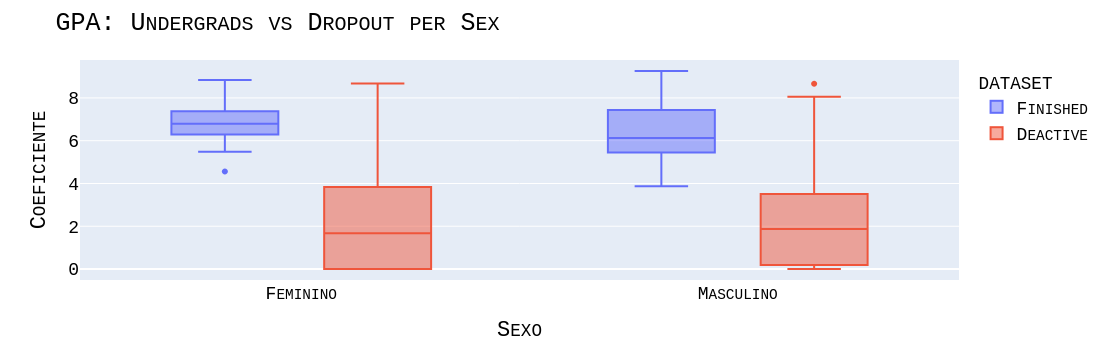

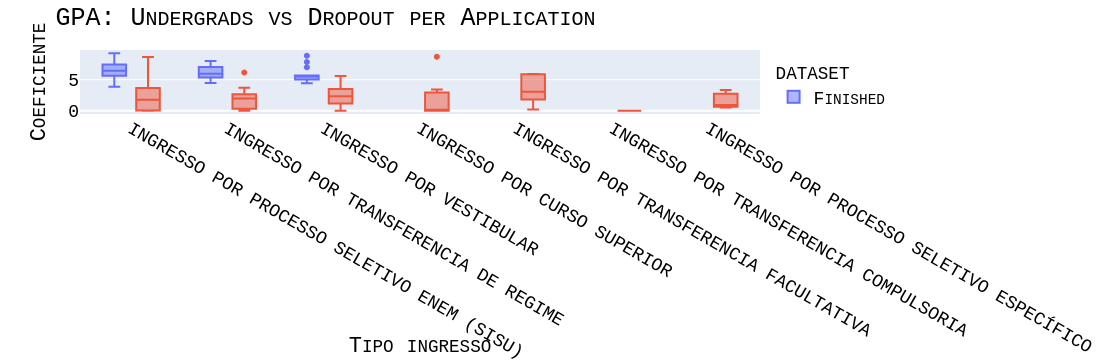

In [65]:
x = pd.concat([
        finished.assign(dataset="Finished"),
        dropout.assign(dataset="Deactive")])

px.box(x, x='Raça', y='Coeficiente', color='dataset').update_layout(title={"text": "GPA: Undergrads vs Dropout per Ethnics"}, font=my_font).show()
px.box(x, x='Sexo', y='Coeficiente', color='dataset').update_layout(title={"text": "GPA: Undergrads vs Dropout per Sex"}, font=my_font).show()
px.box(x, x='Tipo ingresso', y='Coeficiente', color='dataset').update_layout(title={"text": "GPA: Undergrads vs Dropout per Application "}, font=my_font).show()


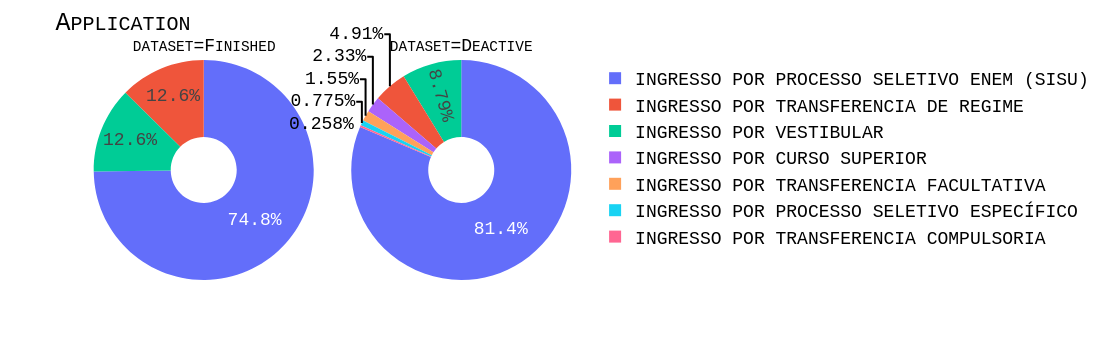

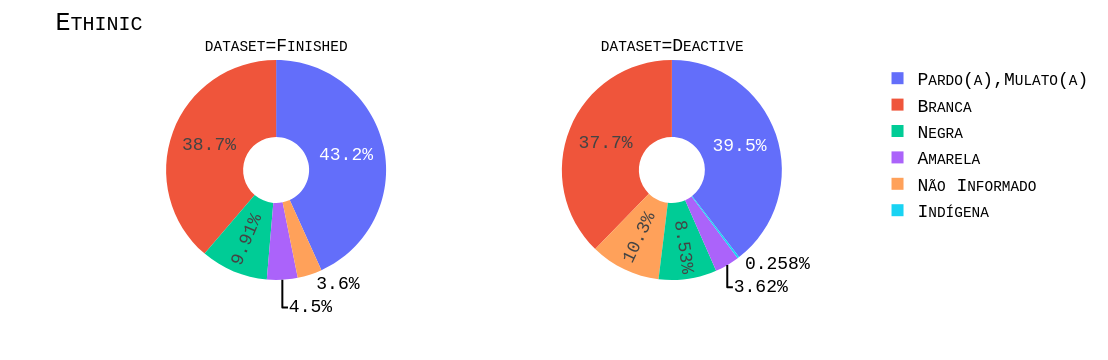

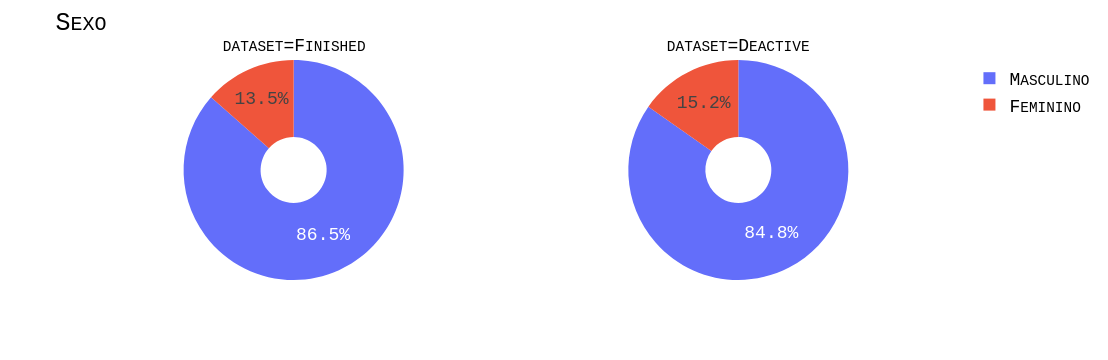

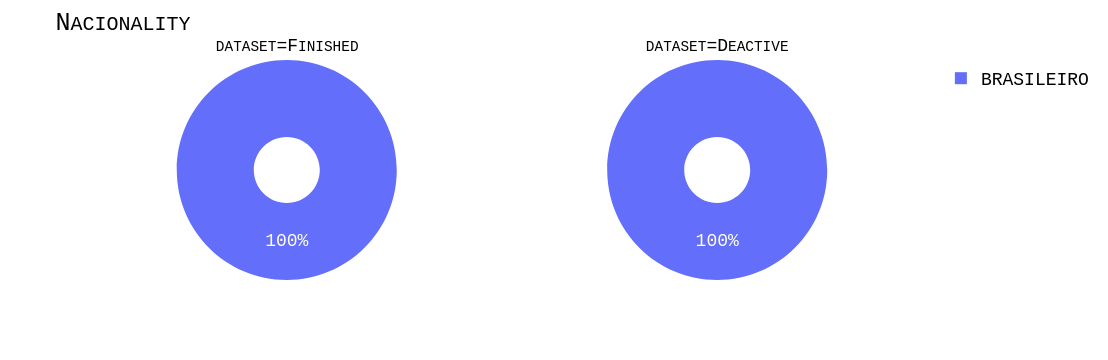

In [66]:
px.pie(
    x, 
    names='Tipo ingresso', 
    facet_col='dataset', 
    hole=0.3,
).update_layout(title={"text": "Application "},font=my_font).show()

px.pie(
    x, 
    names='Raça', 
    facet_col='dataset', 
    hole=0.3,
).update_layout(title={"text": "Ethinic "},font=my_font).show()


px.pie(
    x, 
    names='Sexo', 
    facet_col='dataset', 
    hole=0.3,
).update_layout(title={"text": "Sexo "},font=my_font).show()


px.pie(
    x, 
    names='Nacionalidade', 
    facet_col='dataset', 
    hole=0.3,
).update_layout(title={"text": "Nacionality "},font=my_font).show()

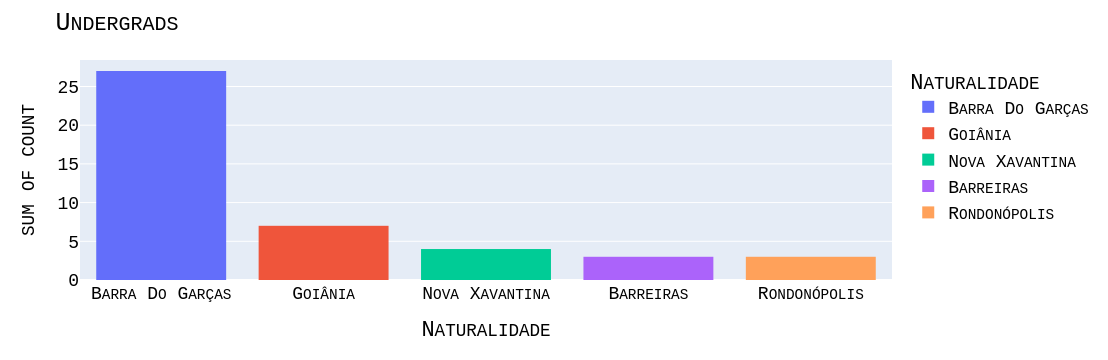

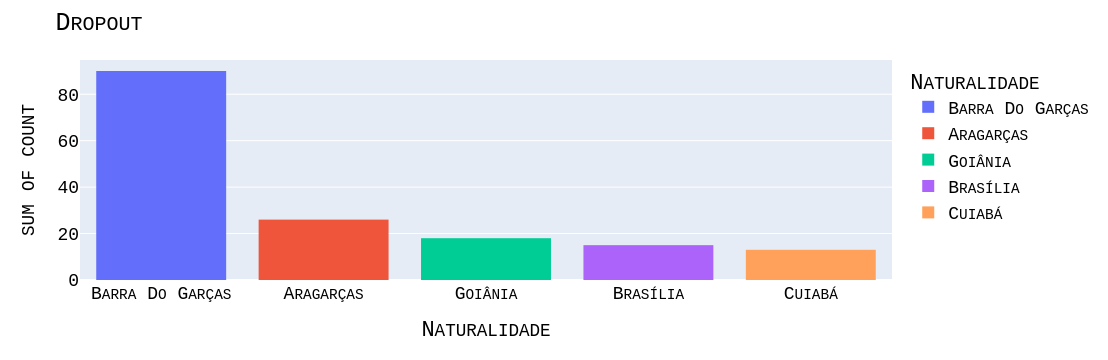

In [67]:
x_grouped =  finished.groupby(['Naturalidade']).size().reset_index(name='count').sort_values(by='count', ascending=False)
y_grouped =  dropout.groupby(['Naturalidade']).size().reset_index(name='count').sort_values(by='count', ascending=False)
px.histogram(x_grouped.head(), x='Naturalidade', y='count', color='Naturalidade').update_layout(title={"text": "Undergrads"}, font=my_font).show()
px.histogram(y_grouped.head(), x='Naturalidade', y='count', color='Naturalidade').update_layout(title={"text": "Dropout"}, font=my_font).show()


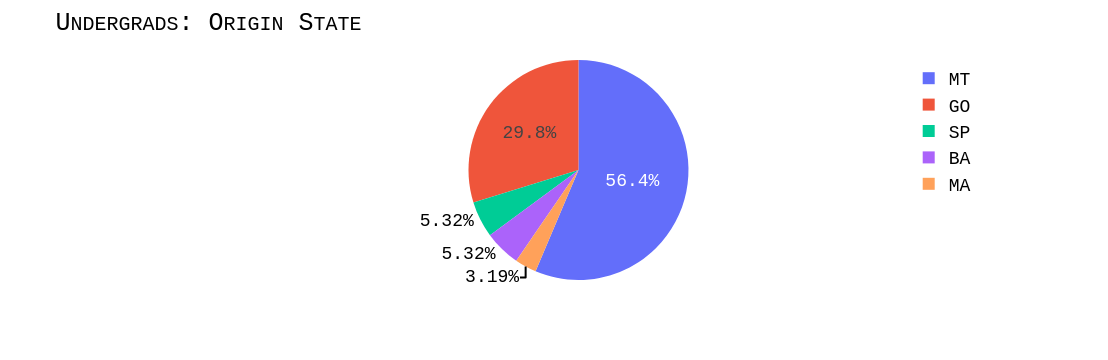

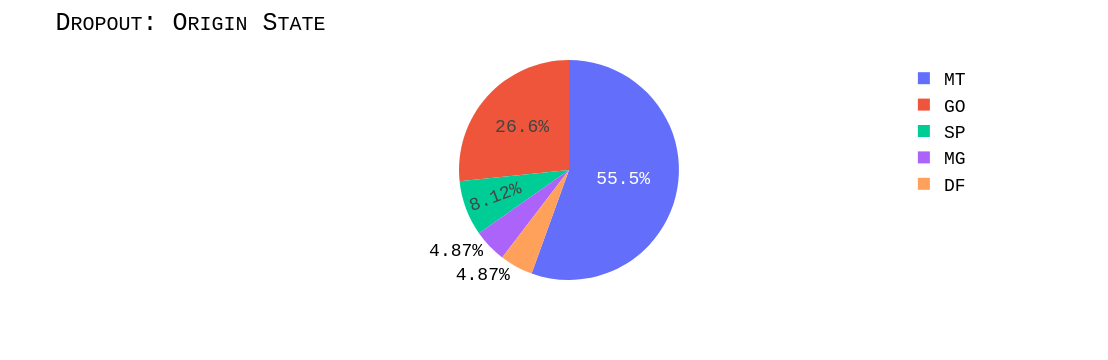

In [68]:
x_grouped =  finished.groupby(['UF Naturalidade']).size().reset_index(name='count').sort_values(by='count', ascending=False)
y_grouped =  dropout.groupby(['UF Naturalidade']).size().reset_index(name='count').sort_values(by='count', ascending=False)
px.pie(x_grouped.head(), names='UF Naturalidade', values='count', color='UF Naturalidade').update_layout(title={"text": "Undergrads: Origin State"}, font=my_font).show()
px.pie(y_grouped.head(), names='UF Naturalidade', values='count', color='UF Naturalidade').update_layout(title={"text": "Dropout: Origin State"}, font=my_font).show()


## Analysing the years of entrance

In [69]:
df['Período ingresso']

1      20141
2      20091
6      20101
11     20091
12     20101
       ...  
480    20121
484    20151
488    20121
492    20131
495    20181
Name: Período ingresso, Length: 111, dtype: int64

In [70]:
deactive['Período ingresso'].isnull().sum()

np.int64(0)

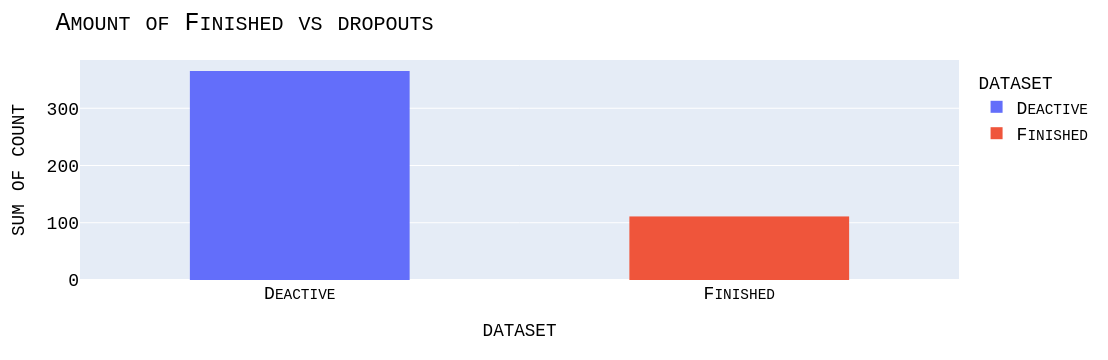

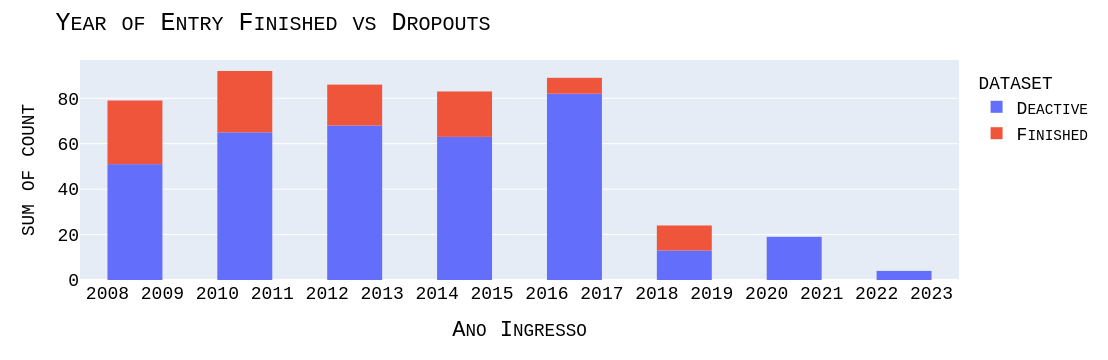

In [71]:
x = pd.concat([
        finished.assign(dataset="Finished"),
        dropout.assign(dataset="Deactive")])

test = x.copy()
# extracting the year of entrance
test = test[test['Período ingresso'] != 0]  # removing those with Período de Ingresso is zero 

test['Ano Ingresso'] = (test['Período ingresso'] / 10).astype("int")

x['Ano Ingresso'] = test['Ano Ingresso']

y = x.groupby(['Ano Ingresso', 'Sexo', 'dataset']).size().reset_index(name='count').sort_values(by='count', ascending=False)
y = y[y['Ano Ingresso'] != 0] # making sure there are not the 22 zero values messing up the plot 
px.histogram(y, x='dataset', y='count', color='dataset').update_layout(bargap=0.5).update_layout(bargap=0.5, title={"text": "Amount of Finished vs dropouts"}, font=my_font).show()
px.histogram(y, x='Ano Ingresso', y='count', color='dataset').update_layout(bargap=0.5, title={"text": "Year of Entry Finished vs Dropouts"}, font=my_font).update_xaxes(tickmode='linear',dtick=1).show()


## Average time which someone evades

In [72]:
test['Ano atual']

KeyError: 'Ano atual'

In [73]:
df

,Data Nascimento,Sexo,Raça,Estrangeiro,Nacionalidade,Naturalidade,UF Naturalidade,Período,Situação atual,Data ocorrência,Estrutura,Período ingresso,Tipo ingresso,IMI,Coeficiente,Tipo de demanda,rga_anonimo,Idade
1,1988-02-06,Feminino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,Paragominas,PA,20221,EXCLUSAO POR CONCLUSAO (FORMADO),2023-02-10,20191,20141,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),68.6,6.95,L4 - Estudante preto pardo ou indígena de esco...,8a417431c97e7d34315177679327cc45414bbf093d4f07...,35.035616
2,1991-11-26,Masculino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,Barra Do Garças,MT,20131,EXCLUSAO POR CONCLUSAO (FORMADO),2013-09-19,20091,20091,INGRESSO POR TRANSFERENCIA DE REGIME,0.0,4.47,NaN,b251f5c111876bb185fdaf7f58535b4a6f3c8e924ab679...,21.830137
6,1992-04-03,Masculino,Branca,Não,BRASILEIRO,Umuarama,PR,20151,EXCLUSAO POR CONCLUSAO (FORMADO),2015-12-17,20091,20101,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),68.9,4.76,NaN,70136b90046e6cb5e440523d6a482e81157591e6a83815...,23.720548
11,1989-05-27,Masculino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,Guirantiga,MT,20122,EXCLUSAO POR CONCLUSAO (FORMADO),2013-06-03,20091,20091,INGRESSO POR VESTIBULAR,0.0,5.58,NaN,02dff9c5e0f19c38bc9220508e270bed2f2cbe716b575f...,24.035616
12,1991-12-08,Feminino,Amarela,Não,BRASILEIRO,Campo Grande,MS,20161,EXCLUSAO POR CONCLUSAO (FORMADO),2016-10-27,20091,20101,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),59.5,6.32,NaN,8bcb312923220611714cdc0a4480c13d300d225bf514f3...,24.904110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480,1994-12-10,Masculino,Negra,Não,BRASILEIRO,Nova Xavantina,MT,20161,EXCLUSAO POR CONCLUSAO (FORMADO),2016-10-27,20091,20121,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),84.2,6.20,Ampla Concorrência,15e2169be3135defaa4214737baff0ac542f87c0d62ac1...,21.895890
484,1994-08-29,Masculino,Negra,Não,BRASILEIRO,Jiparana,RO,20221,EXCLUSAO POR CONCLUSAO (FORMADO),2023-02-10,20191,20151,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),51.8,5.05,L4 - Estudante preto pardo ou indígena de esco...,7c8bf884ece3f8d432120c49f9ec87504f606f14be0818...,28.471233
488,1993-12-09,Masculino,"Pardo(a),Mulato(a)",Não,BRASILEIRO,Barra Do Garças,MT,20162,EXCLUSAO POR CONCLUSAO (FORMADO),2017-05-03,20091,20121,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),77.3,6.74,Ampla Concorrência,dc2c517c61a0df87d0c327bc633bfe8f85a931d0068604...,23.413699
492,1995-03-30,Masculino,Branca,Não,BRASILEIRO,Uruana,GO,20162,EXCLUSAO POR CONCLUSAO (FORMADO),2017-05-03,20091,20131,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),94.8,8.01,L3 - Estudante de escola pública,8e87d3604296808b403387eb520cf1538c205f70f2f1d9...,22.109589


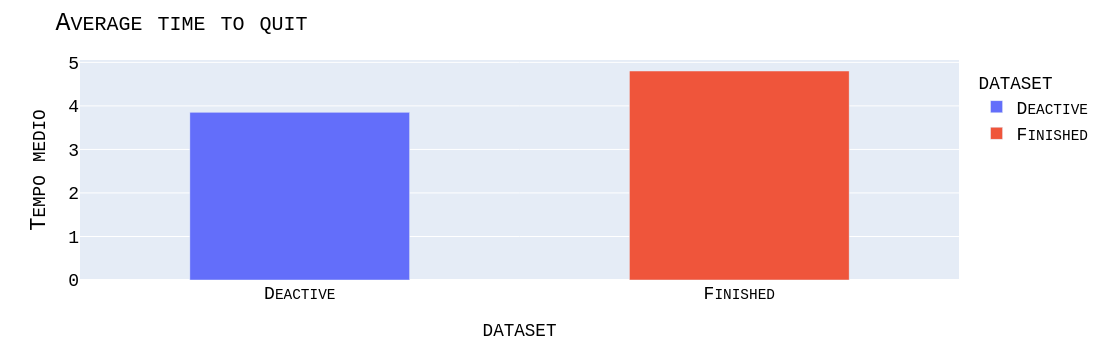

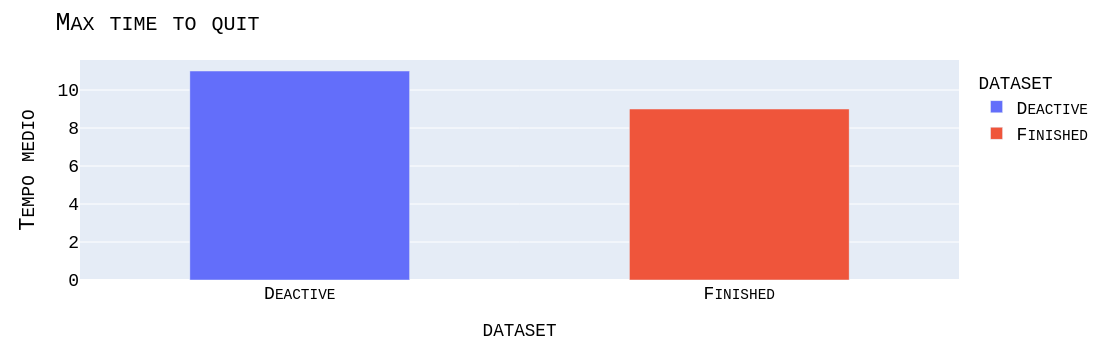

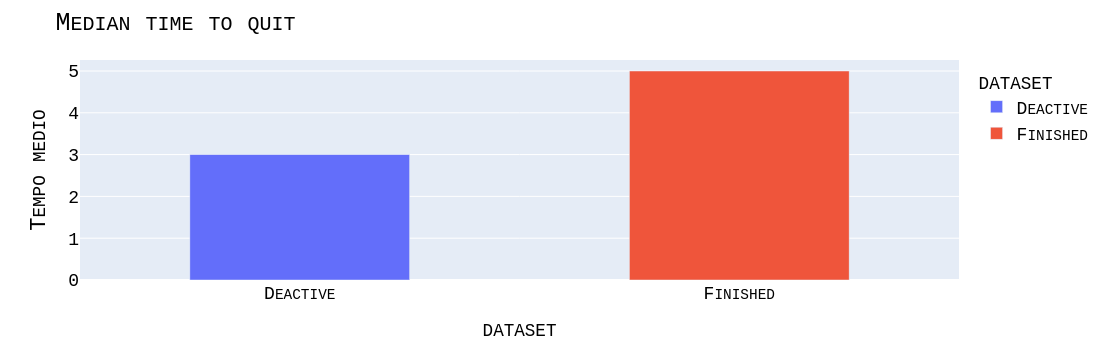

In [74]:
# let us do the math: If we subtract the period the person entered with the current period of the person, 
# we can get how much time they have spent in college 
test = test.dropna(subset=['Data ocorrência'])

test['Data ocorrência'] = test['Data ocorrência'].astype(str)

test['Ano atual']  = np.where (
    test['Data ocorrência'].isnull(),
    (test['Período'] /10), 
     test['Data ocorrência'].str[:4].astype(float)) 
test['Ano atual'] = test['Ano atual'].fillna(0).astype(int)

test['Tempo medio'] = test['Ano atual'] - test['Ano Ingresso']

mean_time = test.groupby('dataset')['Tempo medio'].mean().reset_index()
min_time = test.groupby('dataset')['Tempo medio'].min().reset_index()
max_time = test.groupby('dataset')['Tempo medio'].max().reset_index()
median_time = test.groupby('dataset')['Tempo medio'].median().reset_index()


px.bar(mean_time, x='dataset', y='Tempo medio', color='dataset').update_layout(bargap=0.5, title={"text": "Average time to quit"}, font=my_font).show()
px.bar(max_time, x='dataset', y='Tempo medio', color='dataset').update_layout(bargap=0.5, title={"text": "Max time to quit"}, font=my_font).show()
px.bar(median_time, x='dataset', y='Tempo medio', color='dataset').update_layout(bargap=0.5, title={"text": "Median time to quit"}, font=my_font).show()


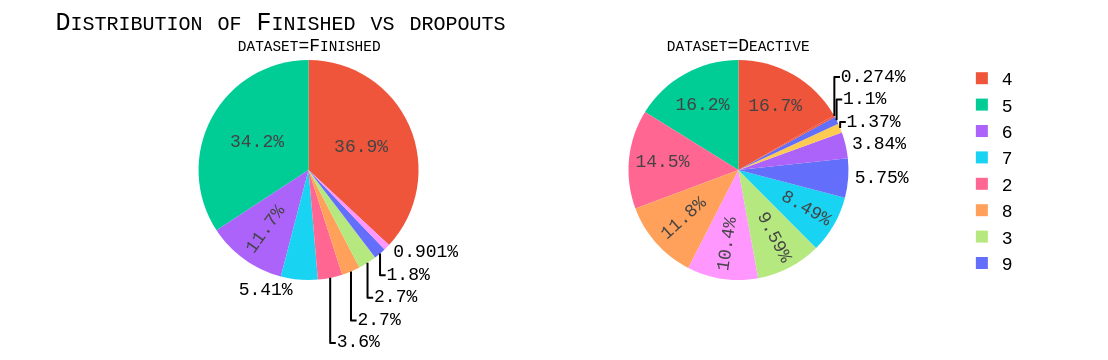

In [75]:
px.pie(test,
      names='Tempo medio',
      color='Tempo medio',
      facet_col='dataset').update_layout(bargap=0.5, title={"text": "Distribution of Finished vs dropouts"}, font=my_font).show()

In [76]:
y = test.groupby(['Sexo', 'dataset']).mean('Tempo medio').reset_index()
y

,Sexo,dataset,Período,Estrutura,Período ingresso,IMI,Coeficiente,Idade,Ano Ingresso,Ano atual,Tempo medio
0,Feminino,Deactive,20177.462963,20131.740741,20144.370370,15.992593,2.509630,24.454845,2014.333333,2017.870370,3.537037
1,Feminino,Finished,20155.733333,20097.666667,20115.000000,59.593333,6.804000,24.598721,2011.400000,2016.133333,4.733333
2,Masculino,Deactive,20173.295820,20121.868167,20135.996785,12.778135,2.320096,25.627802,2013.498392,2017.408360,3.909968
3,Masculino,Finished,20167.614583,20117.041667,20125.062500,75.196875,6.341354,24.466267,2012.406250,2017.218750,4.812500


## Analysing the history

In [77]:
df_merged = pd.merge(test, history, how='right', on='rga_anonimo')
second = df_merged.copy()
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19528 entries, 0 to 19527
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Data Nascimento       14038 non-null  object 
 1   Sexo                  14038 non-null  object 
 2   Raça                  14038 non-null  object 
 3   Estrangeiro           14038 non-null  object 
 4   Nacionalidade         14038 non-null  object 
 5   Naturalidade          13796 non-null  object 
 6   UF Naturalidade       13126 non-null  object 
 7   Período               14038 non-null  float64
 8   Situação atual        14038 non-null  object 
 9   Data ocorrência       14038 non-null  object 
 10  Estrutura             14038 non-null  float64
 11  Período ingresso      14038 non-null  float64
 12  Tipo ingresso         14038 non-null  object 
 13  IMI                   14038 non-null  float64
 14  Coeficiente           14038 non-null  float64
 15  Tipo de demanda    

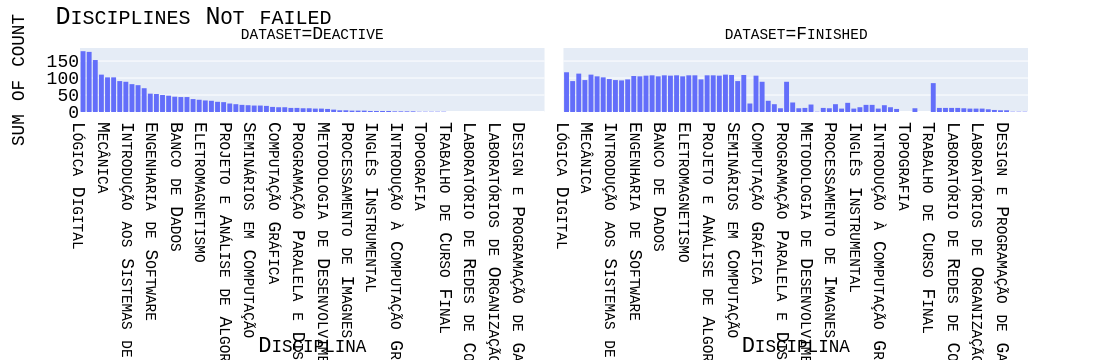

In [78]:
diciplines_grouped = df_merged[df_merged['SF'] == 'AP'] \
    .groupby(['dataset', 'Disciplina']) \
    .size() \
    .reset_index(name='count')\
    .sort_values( by='count', ascending=False)
px.histogram(diciplines_grouped, x='Disciplina', y='count', facet_col='dataset').update_layout(title={"text": "Disciplines Not failed"}, font=my_font) 


In [80]:
df_merged['Disciplina']

0                      Fundamentos de Matemática
1                 Geometria Analítica e Vetorial
2                                 Lógica Digital
3                                  Programação I
4        Práticas de Leitura e Produção de Texto
                          ...                   
19523                                Cálculo III
19524         Programação Paralela e Distribuida
19525            Projeto e Análise de Algoritmos
19526                  Atividades Complementares
19527                    Trabalho de Curso Final
Name: Disciplina, Length: 19528, dtype: object

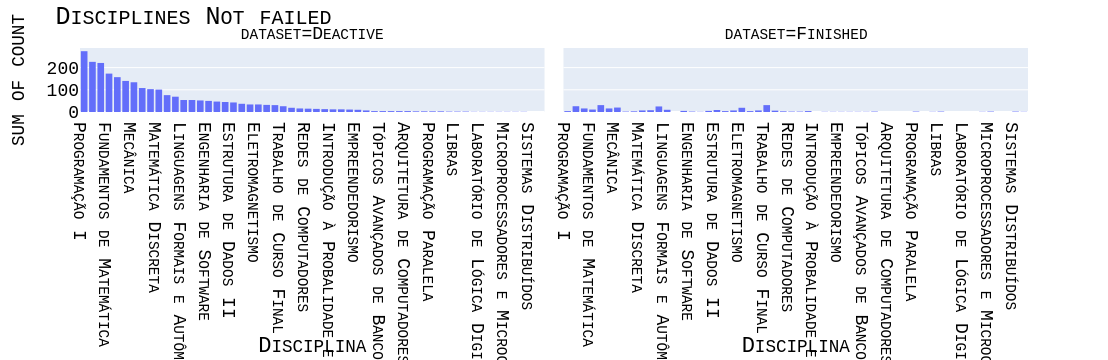

In [79]:
diciplines_grouped = df_merged[df_merged['SF'] == 'RMF'] \
    .groupby(['dataset', 'Disciplina']) \
    .size() \
    .reset_index(name='count')\
    .sort_values( by='count', ascending=False)
px.histogram(diciplines_grouped, x='Disciplina', y='count', facet_col='dataset').update_layout(title={"text": "Disciplines Not failed"}, font=my_font) 


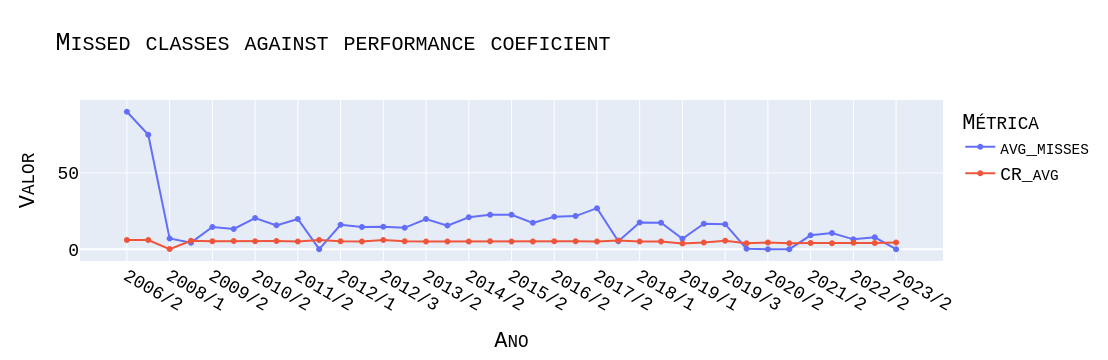

In [19]:
misses_avg = (
    df_merged.groupby("Ano")["FA"]
    .mean()
    .reset_index()
    .rename(columns={"FA": "avg_misses"})
)

cr_avg = (
    df_merged.groupby("Ano")["CR"]
    .mean()
    .reset_index()
    .rename(columns={"CR": "CR_avg"}) 
)

merged_2 = pd.merge(cr_avg, misses_avg, on='Ano')

merged_long = merged_2.melt(
    id_vars="Ano",
    value_vars=["avg_misses", "CR_avg"],
    var_name="Métrica",
    value_name="Valor"
)

px.line(
    merged_long,
    x="Ano",
    y="Valor",
    color="Métrica",
    markers=True,
    title="Missed classes against performance coeficient"
).update_layout(font=my_font).show()


In [20]:
df_merged["Failing"] = df_merged["SF"].isin(["RM", "RMF"]).astype(int)

df_merged["Pass"] = (df_merged["SF"] == "AP").astype(int)


In [21]:
# px.imshow(df_with_fails.corr(numeric_only=True), text_auto=True).show()

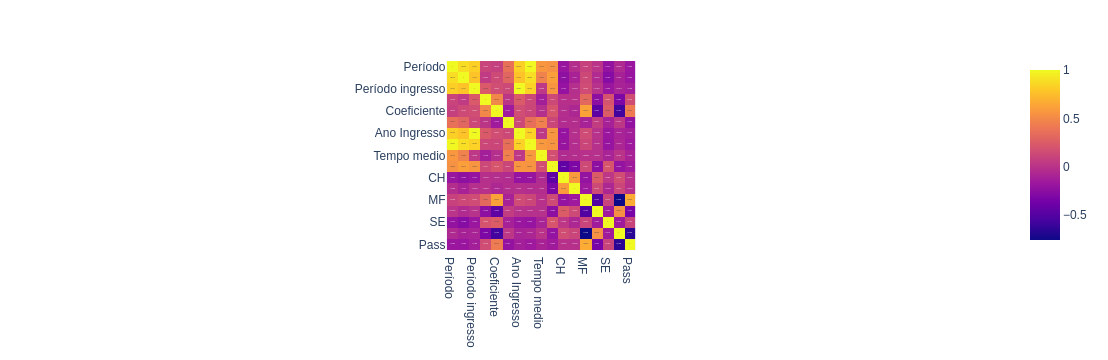

In [22]:
px.imshow(df_merged.corr(numeric_only=True), text_auto=True).show()

# From this it is possible to know the total amount of approved/failed subject for each student

In [23]:
reprovations = df_merged.groupby('rga_anonimo').agg(
        total_failings=('Failing', 'sum'),
        total_passes=('Pass', 'sum')      
)
reprovations['total_subjects_made'] = reprovations['total_failings'] + reprovations['total_passes']

In [24]:
x = reprovations.copy()
x['average_failing'] = ( reprovations['total_failings'] / reprovations['total_subjects_made'] ) * 100
x['average_passing'] = ( reprovations['total_passes'] / reprovations['total_subjects_made'] ) * 100


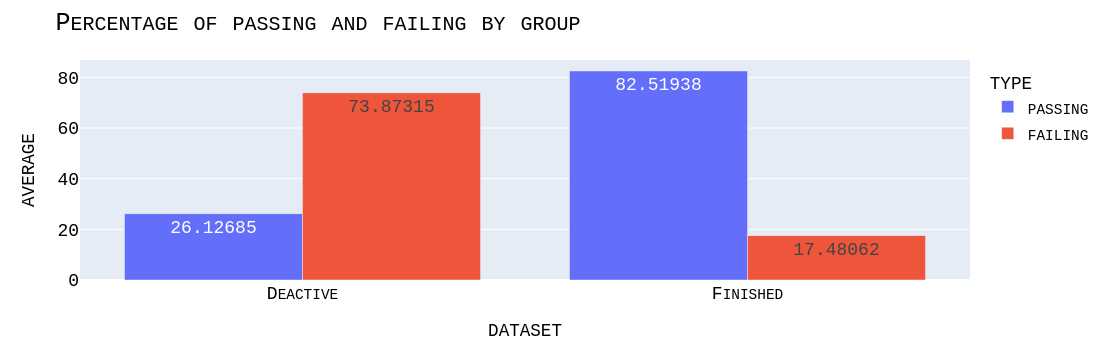

In [25]:
everyone_grouped = pd.merge(
    df_merged[['rga_anonimo', 'dataset', 'Sexo']].drop_duplicates(),
    x,
    on='rga_anonimo',
    how='inner'
)
y = everyone_grouped.groupby("dataset").agg( group_average_passing = ('average_passing', 'mean'),
                                             group_average_failing = ('average_failing', 'mean')).reset_index()
y_melted = y.melt(id_vars="dataset",
                  value_vars=["group_average_passing", "group_average_failing"],
                  var_name="type",
                  value_name="average")

y_melted["type"] = y_melted["type"].str.replace("group_average_", "")

px.bar(
    y_melted,
    x="dataset",
    y="average",
    color="type",
    barmode="group",
    text_auto=True
).update_layout(title={'text': 'Percentage of passing and failing by group'}, font=my_font).show()

## Now analysing the this percentage for each individual group like:
    - Gender
    - Quotas

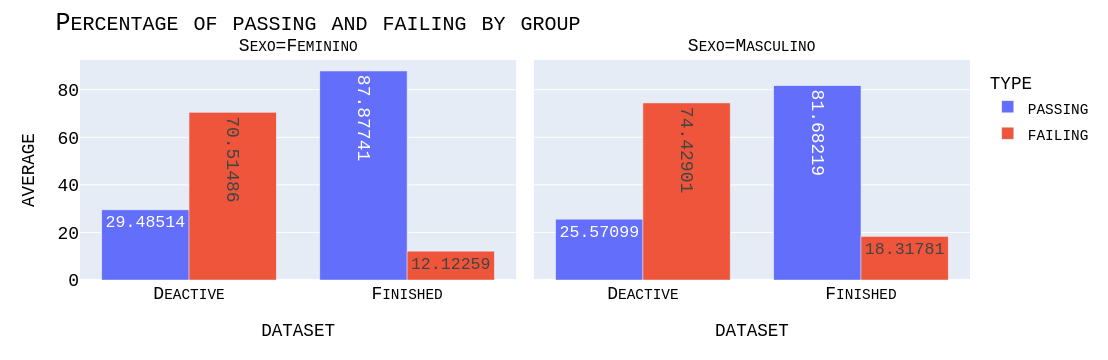

In [26]:
y = everyone_grouped.groupby(["Sexo","dataset"]).agg( group_average_passing = ('average_passing', 'mean'),
                                             group_average_failing = ('average_failing', 'mean')).reset_index()
y_melted = y.melt(id_vars=["Sexo", "dataset"],
                  value_vars=["group_average_passing", "group_average_failing"],
                  var_name="type",
                  value_name="average")

y_melted["type"] = y_melted["type"].str.replace("group_average_", "")

px.bar(
    y_melted,
    x="dataset",
    y="average",
    color="type",
    barmode="group",
    facet_col='Sexo',
    text_auto=True
).update_layout(title={'text': 'Percentage of passing and failing by group'}, font=my_font).show()

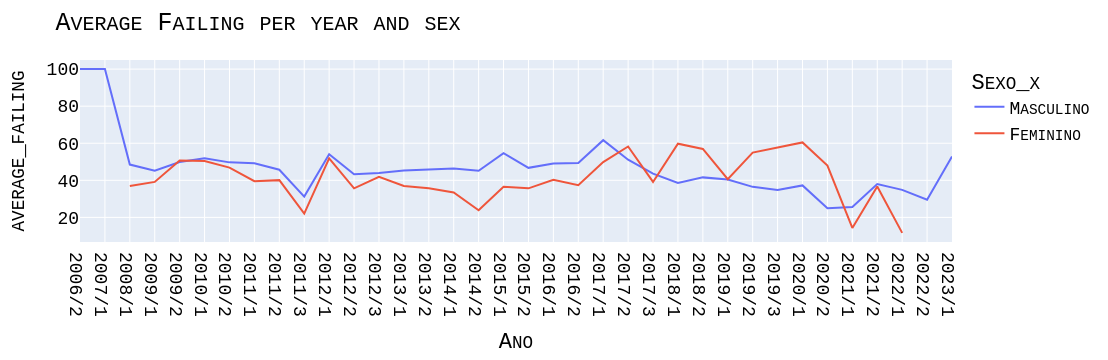

In [27]:
new = pd.merge(second, everyone_grouped, how='inner', on='rga_anonimo')
y = new.groupby(['Ano', 'Sexo_x'])['average_failing'].mean().reset_index()
px.line(y, x='Ano', y='average_failing', color='Sexo_x').update_layout(title={"text": 'Average Failing per year and sex'}, font=my_font)

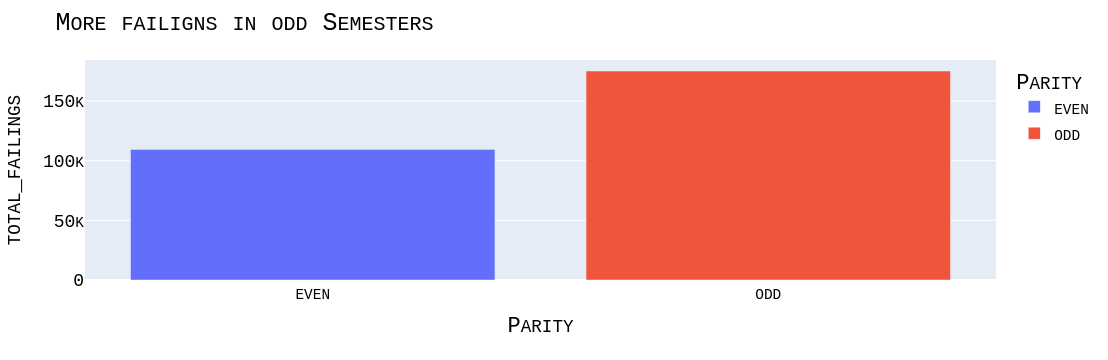

In [28]:
old = new.copy()
old['Semester'] = old['Ano'].str.split("/").str[1].astype(int)
old['Parity'] = old['Semester'] % 2
old['Parity'] = old['Parity'].map({0: "even", 1: "odd"})
x = old.groupby('Parity')['total_failings'].sum().reset_index()
px.bar(x, x='Parity', y='total_failings', color='Parity').update_layout(title = {"text": "More failigns in odd Semesters"}, font=my_font).show()

## Total Amount of Evasion x Entrance per year

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111 entries, 1 to 495
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Data Nascimento   111 non-null    object        
 1   Sexo              111 non-null    object        
 2   Raça              111 non-null    object        
 3   Estrangeiro       111 non-null    object        
 4   Nacionalidade     111 non-null    object        
 5   Naturalidade      110 non-null    object        
 6   UF Naturalidade   111 non-null    object        
 7   Período           111 non-null    int64         
 8   Situação atual    111 non-null    object        
 9   Data ocorrência   111 non-null    datetime64[ns]
 10  Estrutura         111 non-null    int64         
 11  Período ingresso  111 non-null    int64         
 12  Tipo ingresso     111 non-null    object        
 13  IMI               111 non-null    float64       
 14  Coeficiente       111 non-null 

In [29]:
x = pd.concat([
        finished.assign(dataset="Finished"),
        dropout.assign(dataset="Deactive"),
        active.assign(dataset="Active")])

y = x.copy()
y = y[y['Período ingresso'] != 0]  # removing those with Período de Ingresso is zero 
y['Ano Ingresso'] = (y['Período ingresso'] / 10).astype("int")



In [30]:
y['Data ocorrência'] = pd.to_datetime(y['Data ocorrência'])

y['AnoEvento'] = np.where (
    y['dataset'] == 'Deactive',
    y['Data ocorrência'].dt.to_period('Y'),
    np.where(
        y['dataset'] == 'Finished',
        y['Data ocorrência'].dt.to_period('Y'),
        np.where(
            y['dataset'] == 'Active',
            y['Data ocorrência'].dt.to_period('Y'),
            np.nan
        )
    )
)
y['AnoEvento'] = y['AnoEvento'].fillna(y['Período'] / 10)


megazord = y.copy()


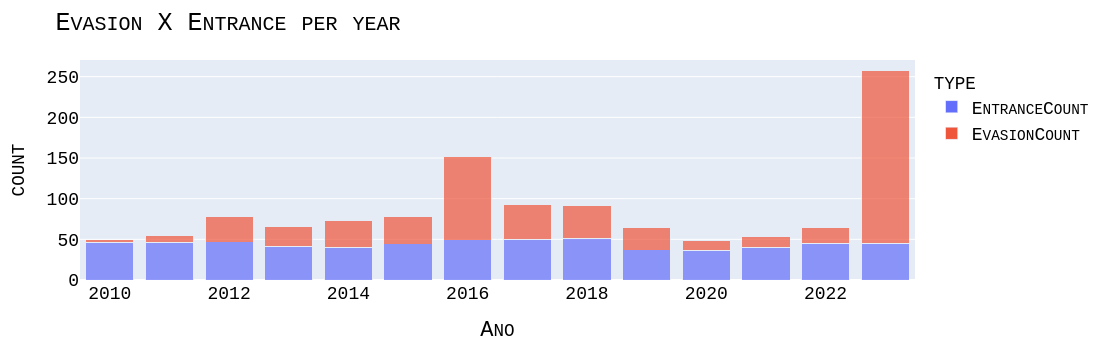

In [31]:
entrance_counts = y.groupby(['Ano Ingresso']).size().reset_index(name='EntranceCount')
leaving_counts = y.groupby(['AnoEvento']).size().reset_index(name='EvasionCount')


entrance_counts.rename(columns={'Ano Ingresso': 'Ano'}, inplace=True)
leaving_counts.rename(columns={'AnoEvento': 'Ano'}, inplace=True)
leaving_counts['Ano'] = leaving_counts['Ano'].dt.year
leaving_counts['Ano'] = leaving_counts['Ano'].astype(int)


counts = pd.merge(entrance_counts, leaving_counts, on='Ano', how='inner')

counts_long = counts.melt(
    id_vars="Ano",
    value_vars=["EntranceCount", "EvasionCount"],
    var_name="type", value_name="count"
)

px.bar(counts_long, x="Ano", y="count", color="type", barmode="stack", opacity=0.7).update_layout(title={"text": "Evasion X Entrance per year"}, font=my_font).show()


## Student's t-Test (independent) → compare average performance coefficient between dropouts and graduates.

In [32]:
history_modified = history.copy()
history_modified.drop(columns={ "Código", "Ano", "Nome da Disciplina", "TU", "SE" ,"MF", "Disciplina", 
                               "Grupo de Disciplinas", "Optativa", "Tipo de Disciplina", "Código"}, inplace=True)
history_modified["Failing"] = history_modified["SF"].isin(["RM", "RMF"]).astype(int)

history_modified["Pass"] = (history_modified["SF"] == "AP").astype(int)

x = history_modified.groupby('rga_anonimo').agg(
        total_failings=('Failing', 'sum'),
        total_passes=('Pass', 'sum'),
        average_cr=('CR', 'mean')
)
x['total_subjects_made'] = x['total_failings'] + x['total_passes']
x['average_failing'] = ( x['total_failings'] / x['total_subjects_made'] ) * 100
x['average_passing'] = ( x['total_passes'] / x['total_subjects_made'] ) * 100
x

,total_failings,total_passes,average_cr,total_subjects_made,average_failing,average_passing
rga_anonimo,,,,,,
005f0115277a00616dc1f82d6a8ab0dcab6dc9c9f5fc324bc89114111235b6f8,27,4,5.354839,31,87.096774,12.903226
006e15f692701bfe282277a51f8fd1db094c66124103bf9a96de2b9eaa82a19f,27,5,4.900000,32,84.375000,15.625000
021b585b6fc82a522e1d11157d544b3769e063a93c3514b050c858dcfcbd4104,51,14,4.545455,65,78.461538,21.538462
023d850bef6e9b93c3386b697f3989baa35cc0f80e796b8234aba801bce7a985,10,1,5.230769,11,90.909091,9.090909
02431d70ee922cfbe69d2551759d1e09a0e320f573a937c4067812bc364d324c,9,0,5.818182,9,100.000000,0.000000
...,...,...,...,...,...,...
ff6d8cd126eae345d6902eb6f02562314e67fa0cb9b06da34f8c96f6260f0f2c,5,0,5.600000,5,100.000000,0.000000
ffa2e9fa2c153ef514ab273fd1a1f8c13cf331ca3a1317d2726f4efa51253853,7,4,3.764706,11,63.636364,36.363636
ffe443cf9a50f96acfebfdb60b402c0475175f373a37fbc773b093662e48e124,15,14,4.509804,29,51.724138,48.275862


In [33]:
df = pd.merge(megazord, x, on='rga_anonimo', how='inner')
df.dropna(how='all', inplace=True)

In [34]:
# additional treatments
df['Naturalidade'] = df['Naturalidade'].fillna('Unknown')
df['Tipo de demanda'] = df['Tipo de demanda'].fillna('Unknown')
df['UF Naturalidade'] = df['UF Naturalidade'].fillna('Unknown')
test2 = df.copy()
test2['Data ocorrência'] = test2['Data ocorrência'].astype(str)
test2['Ano Atual']  = test2['Data ocorrência'].str[:4].astype(int) 
test2['Tempo Medio'] = test2['Ano Atual'] - test2['Ano Ingresso']
df['Ano Atual'] =  test2['Ano Atual'] 
df['Tempo Medio'] =  test2['Tempo Medio']

In [35]:
df.isnull().sum()

Data Nascimento        0
Sexo                   0
Raça                   0
Estrangeiro            0
Nacionalidade          0
Naturalidade           0
UF Naturalidade        0
Período                0
Situação atual         0
Data ocorrência        0
Estrutura              0
Período ingresso       0
Tipo ingresso          0
IMI                    0
Coeficiente            0
Tipo de demanda        0
rga_anonimo            0
Idade                  0
dataset                0
Ano Ingresso           0
AnoEvento              0
total_failings         0
total_passes           0
average_cr             0
total_subjects_made    0
average_failing        0
average_passing        0
Ano Atual              0
Tempo Medio            0
dtype: int64

In [36]:
x = df[df['Idade'].isnull()]

"""
As you can see, there is no longer any NaN values
"""


'\nAs you can see, there is no longer any NaN values\n'

In [37]:
x = df[df['dataset'] == 'Active']
y = df[df['dataset'] == 'Deactive']
z = df[df['dataset'] == 'Finished']

var = z['Tempo Medio']
statistic, p_value = stats.shapiro(var)

print(f"Statistic: {statistic}\nPvalue: {p_value}")

Statistic: 0.8903291274753323
Pvalue: 1.6053522739195584e-07


## It is possible to plot any distribution here. It is commented so you only see what you want.

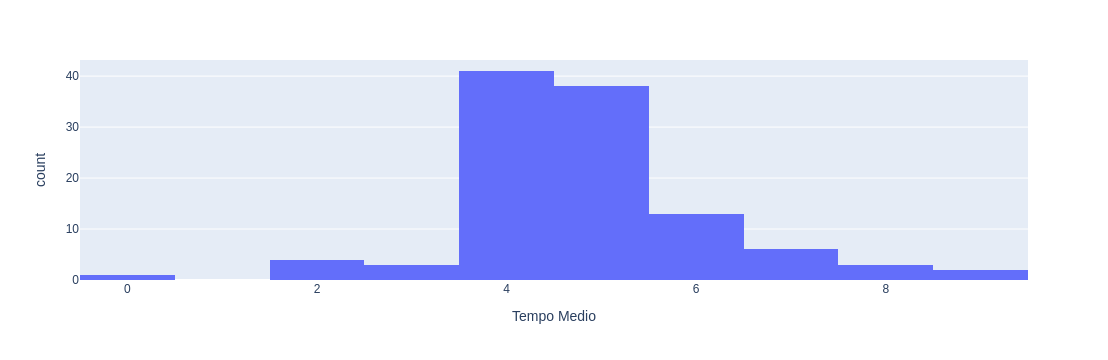

In [38]:
# px.histogram(x, x=var)
# px.histogram(z, x=var)
# px.histogram(y, x=var)
var = z['Tempo Medio']
px.histogram(z, x=var)

In [44]:
var = z['Tempo Medio']
var2 = x['Tempo Medio']

f, p = f_oneway(var, var2)


if p < 0.05:
    print("Reject the null hypothesis: at least one group mean is divergent")
elif p > 0.05:
    print("All group means are the same. Null hypothesis cannot be rejects")

NameError: name 'f_oneway' is not defined

## Removing irrelevant data 

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 664 entries, 0 to 663
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Data Nascimento      664 non-null    object        
 1   Sexo                 664 non-null    object        
 2   Raça                 664 non-null    object        
 3   Estrangeiro          664 non-null    object        
 4   Nacionalidade        664 non-null    object        
 5   Naturalidade         664 non-null    object        
 6   UF Naturalidade      664 non-null    object        
 7   Período              664 non-null    int64         
 8   Situação atual       664 non-null    object        
 9   Data ocorrência      664 non-null    datetime64[ns]
 10  Estrutura            664 non-null    int64         
 11  Período ingresso     664 non-null    int64         
 12  Tipo ingresso        664 non-null    object        
 13  IMI                  664 non-null  

In [80]:
df_to_train = df.drop(columns={"rga_anonimo",
                               "Nacionalidade",
                               "Estrangeiro",
                               "Data Nascimento",
                               "Estrutura",
                               "Situação atual",
                               "Data ocorrência",
                               "Período",
                               "Ano Atual"})


In [81]:
# creating just three possible UF locations
class ClassifyOrigin:
    @staticmethod 
    def classify_origin_state(uf):
        if uf in ["MT", "GO"]:
            return uf
        else:
            return "Outsider"
    @staticmethod
    def classify_origin_city(city):
        if city in ["Barra Do Garcas", "Aragarcas", "Goiania", "Brasilia", "Nova Xavantina", "Cuiaba", "Brasilia", "Sao Paulo"]:
            return city 
        else:
            return "Infrequent City"

df_to_train['UF Naturalidade'] = df_to_train['UF Naturalidade'].apply(ClassifyOrigin.classify_origin_state)
df_to_train['Naturalidade'] = df_to_train['Naturalidade'].apply(ClassifyOrigin.classify_origin_city)
df_to_train['AnoEvento'] = df_to_train['AnoEvento'].astype(str).astype(int)


In [82]:
df_to_train

,Sexo,Raça,Naturalidade,UF Naturalidade,Período ingresso,Tipo ingresso,IMI,Coeficiente,Tipo de demanda,Idade,dataset,Ano Ingresso,AnoEvento,total_failings,total_passes,average_cr,total_subjects_made,average_failing,average_passing,Tempo Medio
0,Feminino,"Pardo(a),Mulato(a)",Infrequent City,Outsider,20141,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),68.6,6.95,L4 - Estudante preto pardo ou indígena de esco...,35.035616,Finished,2014,2023,5,38,4.456522,43,11.627907,88.372093,9
1,Masculino,"Pardo(a),Mulato(a)",Barra Do Garcas,MT,20091,INGRESSO POR TRANSFERENCIA DE REGIME,0.0,4.47,Unknown,21.830137,Finished,2009,2013,21,39,4.046154,60,35.000000,65.000000,4
2,Masculino,Branca,Infrequent City,Outsider,20101,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),68.9,4.76,Unknown,23.720548,Finished,2010,2015,22,36,4.864407,58,37.931034,62.068966,5
3,Masculino,"Pardo(a),Mulato(a)",Infrequent City,MT,20091,INGRESSO POR VESTIBULAR,0.0,5.58,Unknown,24.035616,Finished,2009,2013,9,36,5.108696,45,20.000000,80.000000,4
4,Feminino,Amarela,Infrequent City,Outsider,20101,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),59.5,6.32,Unknown,24.904110,Finished,2010,2016,12,37,4.700000,49,24.489796,75.510204,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,Masculino,"Pardo(a),Mulato(a)",Barra Do Garcas,MT,20201,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),90.3,7.01,L6 - Estudante preto pardo ou indígena de esco...,22.893151,Active,2020,2023,2,40,3.957447,42,4.761905,95.238095,3
660,Masculino,Branca,Infrequent City,GO,20201,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),0.0,0.00,Ampla Concorrência,21.857534,Active,2020,2024,6,0,3.666667,6,100.000000,0.000000,4
661,Masculino,"Pardo(a),Mulato(a)",Barra Do Garcas,MT,20211,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),25.9,2.70,Ampla Concorrência,21.095890,Active,2021,2023,20,9,4.000000,29,68.965517,31.034483,2
662,Masculino,"Pardo(a),Mulato(a)",Aragarcas,GO,20231,INGRESSO POR PROCESSO SELETIVO ENEM (SISU),0.0,1.30,L6 - Estudante preto pardo ou indígena de esco...,18.997260,Active,2023,2023,6,0,3.714286,6,100.000000,0.000000,0


In [89]:
df_to_train_final = pd.get_dummies(df_to_train, 
                                   columns=["Sexo", 
                                            "Raça", 
                                            "Naturalidade",
                                            "UF Naturalidade",
                                            "Tipo ingresso",
                                            "Tipo de demanda"
                                            ],drop_first=True)


In [90]:
X = df_to_train_final.drop('dataset', axis=1)
not_encoded_y = df_to_train_final['dataset']

X_train_troll, X_test_troll, y_train_troll, y_test_troll = train_test_split(X, not_encoded_y, test_size=0.2, random_state=42)

In [91]:
le = LabelEncoder()
y = le.fit_transform(not_encoded_y)
print(list(le.classes_))

['Active', 'Deactive', 'Finished']


In [92]:

X = df_to_train_final.drop('dataset', axis=1)

# Selecionar as 5 melhores features
selector = SelectKBest(score_func=f_regression, k=7)
X_new = selector.fit_transform(X, y)

# Ver as features selecionadas
selected_features = selector.get_feature_names_out(input_features=X.columns)
print("As 5 melhores features selecionadas pelo método de filtragem:")
print(selected_features)

As 5 melhores features selecionadas pelo método de filtragem:
['Período ingresso' 'Ano Ingresso' 'AnoEvento' 'total_passes' 'average_cr'
 'total_subjects_made' 'Tipo de demanda_Unknown']


In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [101]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
preds = rf.predict(X_test)




# saving the model
joblib.dump(rf, "rforest_pkl")

['rforest_pkl']

In [110]:
z = X_train[X_train['IMI'] == 81.3]
z

model = joblib.load('rforest_pkl')



probs = model.predict_proba(z)
print("Class probabilities:", probs)
print("Most likely class:", model.classes_[probs.argmax()])


Class probabilities: [[0.97 0.02 0.01]]
Most likely class: 0


Random Forest's acurracy: 92.48%

Classification report
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        37
           1       0.94      0.97      0.96        66
           2       0.96      0.77      0.85        30

    accuracy                           0.92       133
   macro avg       0.93      0.90      0.91       133
weighted avg       0.93      0.92      0.92       133


Confusion Matrix


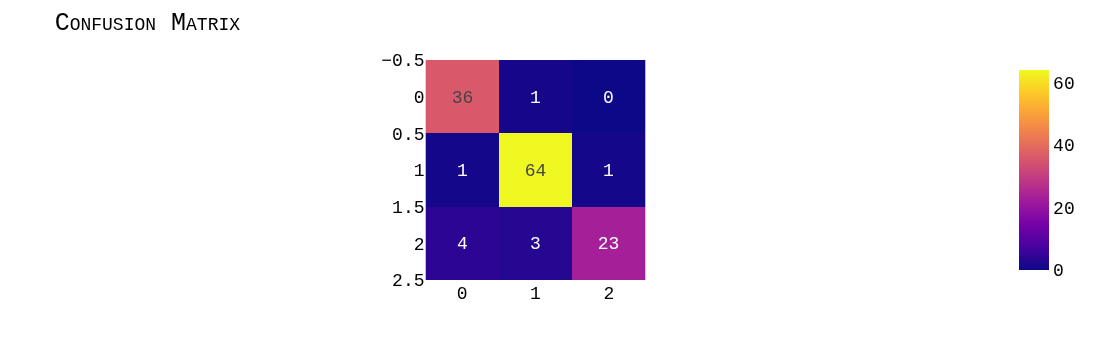

In [96]:
accuracy_rf = accuracy_score(y_test, preds)
print(f"Random Forest's acurracy: {accuracy_rf*100:.2f}%")

print("\nClassification report")
print(classification_report(y_test, preds))

print("\nConfusion Matrix")
cm = confusion_matrix(y_test, preds)
fig = px.imshow(cm, text_auto=True).update_layout(title={"text": "Confusion Matrix"}, font=my_font).show()


Logistic Regression's acurracy: 92.48%

Classification report
              precision    recall  f1-score   support

           0       0.85      0.95      0.90        37
           1       0.96      0.97      0.96        66
           2       1.00      0.83      0.91        30

    accuracy                           0.93       133
   macro avg       0.94      0.92      0.92       133
weighted avg       0.94      0.93      0.93       133


Confusion Matrix


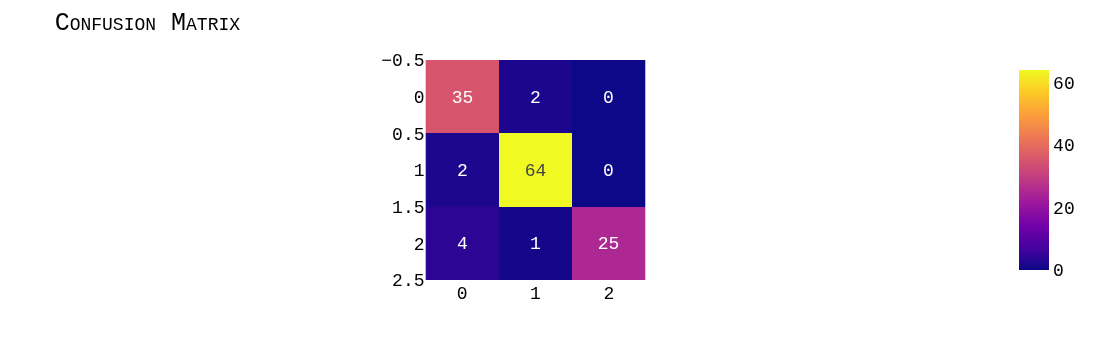

In [97]:
# as recommended, scaling the data increases overall performance 
scaler = StandardScaler()
scaler.fit(X)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
preds = lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, preds)
print(f"Logistic Regression's acurracy: {accuracy_rf*100:.2f}%")

print("\nClassification report")
print(classification_report(y_test, preds))

print("\nConfusion Matrix")
cm = confusion_matrix(y_test, preds)
fig = px.imshow(cm, text_auto=True).update_layout(title={"text": "Confusion Matrix"}, font=my_font).show()


In [98]:

model = CatBoostClassifier(
    iterations=100,      
    learning_rate=0.1,   
    depth=6,              
    verbose=0             
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy_catboost = accuracy_score(y_test, preds)
print(f"Catboost's acurracy: {accuracy_catboost*100:.2f}%")

print("\nClassification report")
print(classification_report(y_test, predictions))

Catboost's acurracy: 93.23%

Classification report
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        37
           1       0.94      0.97      0.96        66
           2       0.96      0.77      0.85        30

    accuracy                           0.92       133
   macro avg       0.93      0.90      0.91       133
weighted avg       0.93      0.92      0.92       133



Catboost's acurracy: 92.48%

Classification report
              precision    recall  f1-score   support

      Active       0.88      0.97      0.92        37
    Deactive       0.94      0.97      0.96        66
    Finished       0.96      0.77      0.85        30

    accuracy                           0.92       133
   macro avg       0.93      0.90      0.91       133
weighted avg       0.93      0.92      0.92       133


Confusion Matrix


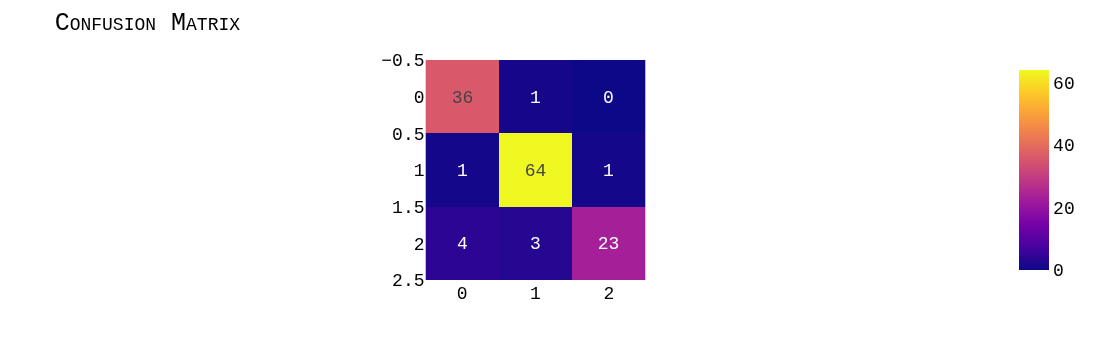

In [99]:
# Did not used a labeled y
model = CatBoostClassifier(
    iterations=100,      
    learning_rate=0.05,   
    depth=6,              
    verbose=0             
)

model.fit(X_train_troll, y_train_troll)

preds = model.predict(X_test_troll)
accuracy_catboost = accuracy_score(y_test_troll, preds)
print(f"Catboost's acurracy: {accuracy_catboost*100:.2f}%")

print("\nClassification report")
print(classification_report(y_test_troll, preds))


print("\nConfusion Matrix")
cm = confusion_matrix(y_test_troll, preds)
fig = px.imshow(cm, text_auto=True).update_layout(title={"text": "Confusion Matrix"}, font=my_font).show()
